In [1]:
# pip install deprecated


In [2]:

# pip install mftool


In [3]:
from mftool import Mftool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
help(Mftool)

Help on class Mftool in module mftool.mftool:

class Mftool(builtins.object)
 |  class which implements all the functionality for
 |  Mutual Funds in India
 |
 |  Methods defined here:
 |
 |  __init__(self)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  calculate_balance_units_value(self, code, balance_units, as_json=False)
 |      gets the market value of your balance units for a given scheme code
 |      :param code: scheme code, balance_units : current balance units
 |      :param balance_units: balance units
 |      :param as_json: default false
 |      :return: dict or None
 |
 |  calculate_returns(self, code, balanced_units, monthly_sip, investment_in_months, as_json=False)
 |      gets the market value of your balance units for a given scheme code
 |      :param code: scheme-code,
 |      :param balanced_units : current balance units
 |      :param monthly_sip: monthly investment in scheme
 |      :param investment_in_months: months
 |      :param 

In [5]:
mf=Mftool()

In [6]:
all_scheme_codes=mf.get_scheme_codes()
all_scheme_codes

{'Scheme Code': 'Scheme Name',
 '119551': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW',
 '119552': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - MONTHLY IDCW',
 '119553': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - Direct - Quarterly IDCW',
 '108272': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - REGULAR - IDCW',
 '110282': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - REGULAR - MONTHLY IDCW',
 '108274': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - REGULAR - Quarterly IDCW',
 '110490': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - retail - monthly IDCW',
 '106157': 'Aditya Birla Sun Life Banking & PSU Debt Fund  - retail - quarterly IDCW',
 '108273': 'Aditya Birla Sun Life Banking & PSU Debt Fund - Regular Plan-Growth',
 '103176': 'Aditya Birla Sun Life Banking & PSU Debt Fund - Retail Plan-Growth',
 '119550': 'Aditya Birla Sun Life Banking & PSU Debt Fund- Direct Plan-Growth',
 '128952': 'Axis Banking & PSU Debt Fund - Direct Pla

In [22]:
details=mf.get_available_schemes('Large')
details

{'119436': 'Aditya Birla Sun Life Large & Mid Cap Fund - Growth - Direct Plan',
 '100033': 'Aditya Birla Sun Life Large & Mid Cap Fund - Regular Growth',
 '119433': 'Aditya Birla Sun Life Large & Mid Cap Fund -Direct - IDCW',
 '100034': 'Aditya Birla Sun Life Large & Mid Cap Fund -Regular - IDCW',
 '145110': 'Axis Large & Mid Cap Fund - Direct Plan - Growth',
 '145109': 'Axis Large & Mid Cap Fund - Direct Plan - IDCW',
 '145112': 'Axis Large & Mid Cap Fund - Regular Plan - Growth',
 '145111': 'Axis Large & Mid Cap Fund - Regular Plan - IDCW',
 '152408': 'Bajaj Finserv Large and Mid Cap Fund- Direct Plan- Growth',
 '152405': 'Bajaj Finserv Large and Mid Cap Fund- Direct Plan- IDCW',
 '152406': 'Bajaj Finserv Large and Mid Cap Fund- Regular Plan- Growth',
 '152407': 'Bajaj Finserv Large and Mid Cap Fund- Regular Plan- IDCW',
 '118419': 'Bandhan Large & Mid Cap Fund - Direct Plan - Growth',
 '118420': 'Bandhan Large & Mid Cap Fund - Direct Plan - IDCW',
 '108596': 'Bandhan Large & Mid Cap

In [33]:
codes=['149389','149072','149463','143247','128627']
df1=pd.DataFrame()

for i in codes:
    history_nav=mf.get_scheme_historical_nav(i,as_Dataframe=True)
    name=mf.get_scheme_details(i)['scheme_name']
    df1[name]=history_nav['nav']

df1.reset_index()

,date,ICICI Prudential Nifty Midcap 150 Index Fund - Direct Plan - Growth,ICICI Prudential Nifty FMCG ETF,ICICI Prudential Nifty Auto ETF,ICICI Prudential BSE 500 ETF,HDFC Banking and PSU Debt Fund - IDCW Option
0,19-12-2025,19.76470,58.54540,28.42660,39.98000,10.13330
1,18-12-2025,19.53880,58.29470,28.08230,39.66910,10.13290
2,17-12-2025,19.49730,58.35590,28.25440,39.68420,10.13040
3,16-12-2025,19.60440,58.63420,28.30900,39.80870,10.13120
4,15-12-2025,19.75660,58.63970,28.33570,40.07410,10.12900
...,...,...,...,...,...,...
979,29-12-2021,10.13580,371.22390,NaN,24.48670,10.13580
980,28-12-2021,10.12160,372.56890,NaN,24.49570,10.13430
981,27-12-2021,10.00950,369.77060,NaN,24.26710,10.13510
982,24-12-2021,9.97670,370.08230,NaN,24.16250,10.13000


In [40]:
columns=df1.columns.to_list

df1.reset_index(inplace=True)

df1['date']=pd.to_datetime(df1['date'],dayfirst=False)

In [66]:
nav_cols = [c for c in df1.columns if c != 'date']

for col in nav_cols:
    
    df1[col] = pd.to_numeric(df1[col].astype(str).str.replace(',', ''), errors='coerce')



# df1.drop(columns=['level_0','index'],inplace=True)

df1


,date,ICICI Prudential Nifty Midcap 150 Index Fund - Direct Plan - Growth,ICICI Prudential Nifty FMCG ETF,ICICI Prudential Nifty Auto ETF,ICICI Prudential BSE 500 ETF,HDFC Banking and PSU Debt Fund - IDCW Option
968,2022-01-13,10.6840,381.7925,116.8465,25.9063,10.1325
967,2022-01-14,10.6805,379.0715,116.4338,25.9200,10.1335
966,2022-01-17,10.7124,380.7989,118.8109,26.0016,10.1342
965,2022-01-18,10.5159,375.9279,115.9738,25.6668,10.1327
964,2022-01-19,10.4996,371.9489,116.7995,25.4990,10.1330
...,...,...,...,...,...,...
4,2025-12-15,19.7566,58.6397,28.3357,40.0741,10.1290
3,2025-12-16,19.6044,58.6342,28.3090,39.8087,10.1312
2,2025-12-17,19.4973,58.3559,28.2544,39.6842,10.1304
1,2025-12-18,19.5388,58.2947,28.0823,39.6691,10.1329


In [67]:
df1 = df1.dropna(subset=nav_cols)



In [68]:
df_norm = df1.copy()
df_norm[nav_cols] = (df1[nav_cols] / df1[nav_cols].iloc[0]) * 100

df_norm

,date,ICICI Prudential Nifty Midcap 150 Index Fund - Direct Plan - Growth,ICICI Prudential Nifty FMCG ETF,ICICI Prudential Nifty Auto ETF,ICICI Prudential BSE 500 ETF,HDFC Banking and PSU Debt Fund - IDCW Option
968,2022-01-13,100.000000,100.000000,100.000000,100.000000,100.000000
967,2022-01-14,99.967241,99.287309,99.646802,100.052883,100.009869
966,2022-01-17,100.265818,99.739754,101.681180,100.367864,100.016778
965,2022-01-18,98.426619,98.463930,99.253123,99.075514,100.001974
964,2022-01-19,98.274055,97.421741,99.959776,98.427796,100.004935
...,...,...,...,...,...,...
4,2025-12-15,184.917634,15.359050,24.250363,154.688628,99.965458
3,2025-12-16,183.493074,15.357609,24.227512,153.664167,99.987170
2,2025-12-17,182.490640,15.284716,24.180784,153.183589,99.979275
1,2025-12-18,182.879072,15.268687,24.033497,153.125302,100.003948


In [70]:
df_plot = df_norm.melt(id_vars='date', var_name='Mutual_Fund', value_name='Growth_Index',ignore_index=True)

#here we have data that is having nav in sep col for each mf we need to pivot it so that the 
#data is organized in such date remains as same in a col but each mf name is pivoted in such a manner that they appear multiple times based on
#which date we are viewing
#done so that the seaborn can plot them in a single line graph


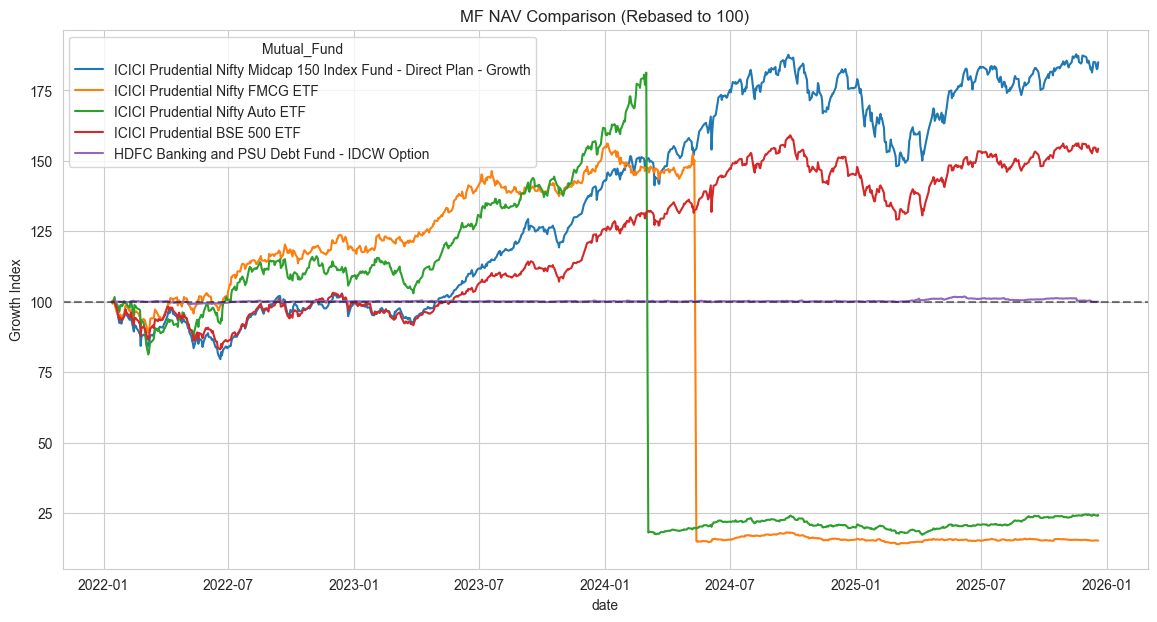

In [71]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_plot, x='date', y='Growth_Index', hue='Mutual_Fund')

plt.axhline(100, color='black', linestyle='--', alpha=0.5)
plt.title('MF NAV Comparison (Rebased to 100)')
plt.ylabel('Growth Index')
plt.show()

In [ ]:
# from the above we can see that at macro level all the mutual funds schemes are running 